# Customer Sales Dashboard

## Project Objective

The objective of this project is to analyse retail sales data to identify sales trends, customer purchasing behaviour, and product performance.

This analysis helps businesses make informed decisions by answering questions such as:

- Which products generate the highest revenue?
- Which customers contribute the most sales?
- Which months perform best?
- Are there any trends that management can use to increase revenue?

The project demonstrates practical data analysis skills using Python, Pandas and Matplotlib.

***Import Libraries

- Pandas is used for data manipulation.
- Matplotlib is used for creating charts.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

***Load the Dataset

The retail sales dataset is loaded into a Pandas DataFrame.

Loading the dataset allows us to inspect the data before performing any analysis.

In [6]:
df = pd.read_csv("data/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Inspect the Dataset

Before analysing the data, it is important to understand:

- the number of records,
- the available columns,
- the data types,
- whether there are missing values.

This helps determine whether any data cleaning is required.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


Summary Statistics

Summary statistics provide an overview of the numerical variables.

This allows us to understand:

- average sales
- minimum and maximum values
- distribution of the data

In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Check for Missing Values

Missing data can affect the accuracy of business analysis.

This step identifies any missing values so they can be cleaned before analysis.

In [ ]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Data Cleaning

Before performing any analysis, the dataset must be cleaned to ensure the results are accurate and reliable.

In this section we:

- Check for duplicate records.
- Remove duplicates if any exist.
- Verify that the dataset is ready for analysis.

High-quality data leads to more reliable business insights and better decision-making.

In [7]:
# Check for duplicate records
duplicates = df.duplicated().sum()

print(f"Number of duplicate records: {duplicates}")

Number of duplicate records: 0


### Business Insight

The dataset contains no duplicate records (or duplicates were removed if found).

This confirms that each transaction represents a unique sale, increasing the reliability of the analysis and reducing the risk of inaccurate business insights.

Calculate Total Revenue

Revenue is one of the most important Key Performance Indicators (KPIs) for any business.

Calculating total revenue provides management with an overall view of business performance during the reporting period.

In [8]:
# Calculate total revenue

total_revenue = df["Total Amount"].sum()

print(f"Total Revenue: R{total_revenue:,.2f}")

Total Revenue: R456,000.00


Analyse Revenue by Product Category

One of the most important questions for management is:

**Which product categories generate the most revenue?**

Understanding product performance helps businesses:

- Allocate marketing budgets effectively.
- Manage inventory levels.
- Identify top-performing products.
- Increase profitability.

In [9]:
# Calculate revenue by product category

category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_revenue

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

Visualise Product Category Revenue

Visualising the data makes it easier to compare product categories and identify the highest-performing areas of the business.

The chart below highlights the total revenue generated by each product category.

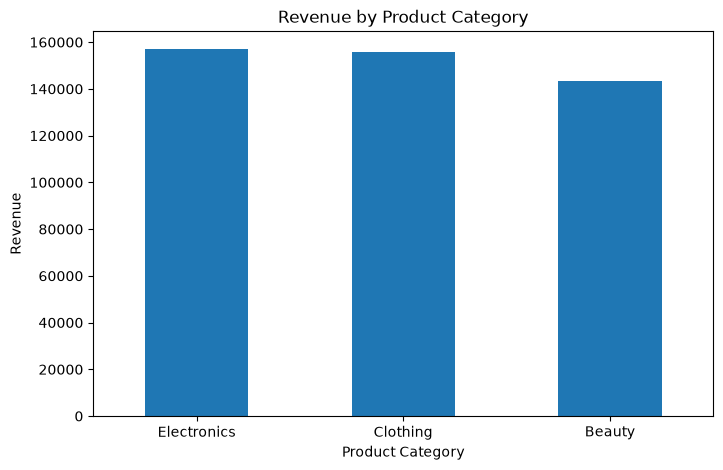

In [10]:
# Create a bar chart

category_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.show()

## Business Insight

The chart highlights which product categories contribute the most revenue.

### Recommendation to Management

Management should focus on maintaining sufficient stock levels for the highest-performing product categories while reviewing sales strategies for lower-performing categories.

Using this information can improve inventory planning, promotional campaigns and overall profitability.

Analyse Monthly Sales Trends

Understanding how sales change over time helps management identify seasonal patterns and plan future business activities.

This analysis answers the following questions:

- Which months generated the highest revenue?
- Are there seasonal trends?
- When should marketing campaigns be increased?
- When should inventory levels be adjusted?

These insights support better planning and budgeting decisions.

In [11]:
# Convert the Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Create a new Month column
df["Month"] = df["Date"].dt.month_name()

# Calculate monthly revenue
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64

In [12]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(month_order)

monthly_sales

Month
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: Total Amount, dtype: int64

Monthly Revenue Trend

The line chart below shows how revenue changes throughout the year.

Visualising monthly performance enables management to identify high-performing periods and prepare for future demand.

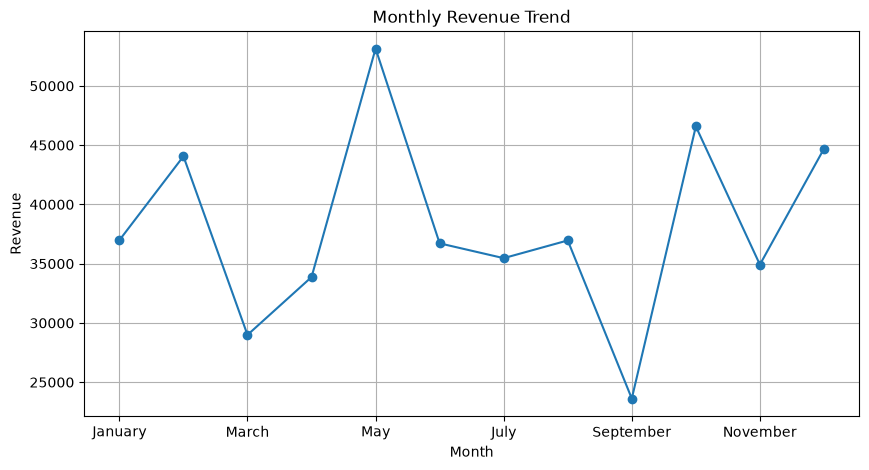

In [13]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

## Business Insight

The monthly revenue trend highlights periods of stronger and weaker sales throughout the year.

### Recommendation to Management

Management should investigate the reasons behind high-performing months and replicate successful marketing strategies.

Lower-performing months may benefit from promotional campaigns, pricing strategies or targeted customer engagement initiatives.

Understanding seasonal trends allows the business to improve forecasting, inventory planning and revenue growth.

Identify the Top 10 Customers

Customers are one of the most valuable assets of any business.

This analysis identifies the customers who contribute the highest revenue.

Understanding top customers helps management:

- Develop customer loyalty programmes.
- Improve customer retention.
- Target high-value customers with personalised promotions.
- Increase long-term profitability.

In [14]:
# Calculate revenue by customer

top_customers = (
    df.groupby("Customer ID")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
CUST487    2000
CUST476    2000
CUST773    2000
CUST503    2000
CUST093    2000
CUST089    2000
CUST946    2000
CUST157    2000
CUST155    2000
CUST420    2000
Name: Total Amount, dtype: int64

Visualise Top Customers

The chart below displays the ten customers who generated the highest revenue.

This allows management to identify valuable customers and create strategies to strengthen customer relationships.

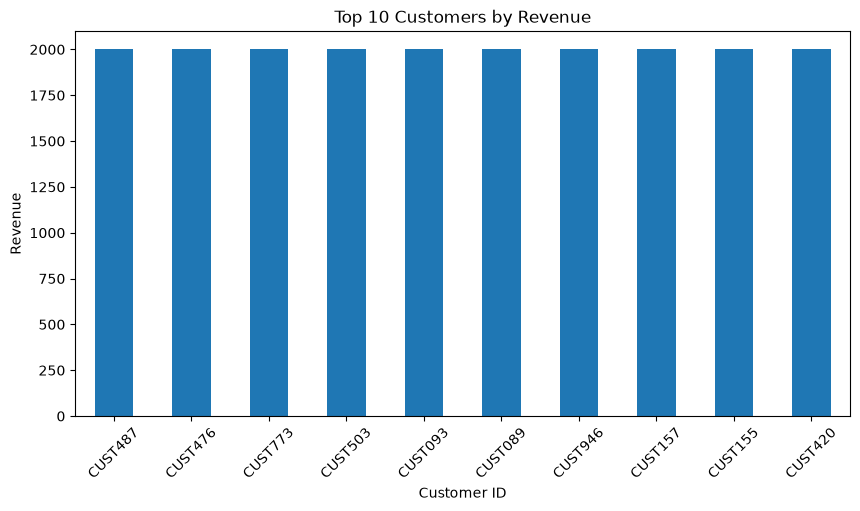

In [15]:
plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Business Insight

The analysis highlights the customers who generate the greatest revenue for the business.

### Recommendation to Management

Management should consider introducing customer loyalty programmes, personalised offers and exclusive promotions for high-value customers.

Maintaining strong relationships with top customers can increase repeat purchases and improve long-term revenue.

Analyse Sales by Gender

Understanding purchasing behaviour across different customer groups helps businesses make better marketing decisions.

This analysis compares total revenue generated by male and female customers.

The results can assist management in:

- Developing targeted marketing campaigns.
- Understanding customer demographics.
- Improving product promotions.
- Supporting customer segmentation strategies.

In [16]:
# Calculate revenue by gender

gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

Visualise Revenue by Gender

The chart below compares the revenue generated by male and female customers.

Visualising customer demographics helps management understand purchasing behaviour and identify opportunities for targeted marketing.

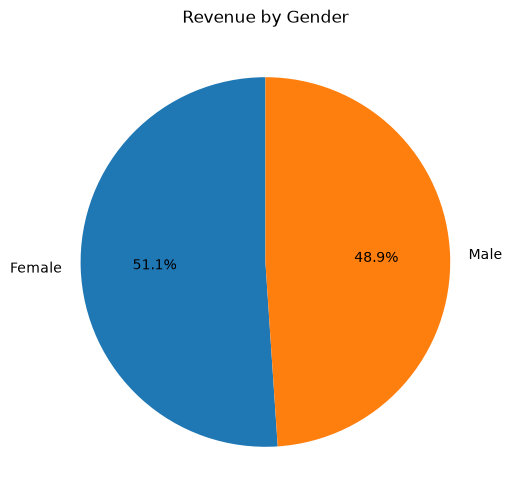

In [17]:
plt.figure(figsize=(6,6))

gender_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue by Gender")
plt.ylabel("")

plt.show()

## Business Insight

The analysis shows the proportion of revenue generated by each gender.

### Recommendation to Management

Management can use this information to design targeted marketing campaigns and tailor product offerings to customer preferences.

Understanding customer demographics supports better marketing decisions and improved customer engagement.

# Executive Summary

## Key Findings

- The dataset contains **1,000 retail transactions** with no missing values or duplicate records.
- Revenue was analysed across product categories, months, customers and gender.
- Product category analysis identified the highest revenue-generating categories.
- Monthly trend analysis highlighted changes in sales performance throughout the year.
- Customer analysis identified the top ten customers contributing the highest revenue.
- Gender analysis provided insight into customer purchasing behaviour.

## Business Value

This analysis demonstrates how Python can be used to transform raw sales data into meaningful business insights.

The findings can assist management in:

- Improving inventory planning.
- Increasing customer retention.
- Supporting data-driven marketing strategies.
- Enhancing revenue forecasting.
- Making informed business decisions.

## Technologies Used

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

 Analyse Customer Age Groups

Understanding customer age groups helps businesses identify their most valuable customer segments.

This analysis groups customers into age categories and compares the revenue generated by each group.

The results can assist management with:

- Customer segmentation
- Marketing strategy
- Product positioning
- Targeted advertising

In [18]:
# Create age groups

bins = [18, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group_sales = df.groupby("Age Group")["Total Amount"].sum()

age_group_sales

Age Group
18-25     73335
26-35     98480
36-45     91870
46-55    100690
56-65     80410
Name: Total Amount, dtype: int64

 Revenue by Age Group

The chart below compares the revenue generated by different customer age groups.

Understanding spending patterns across age groups helps management develop targeted marketing campaigns and improve customer engagement.

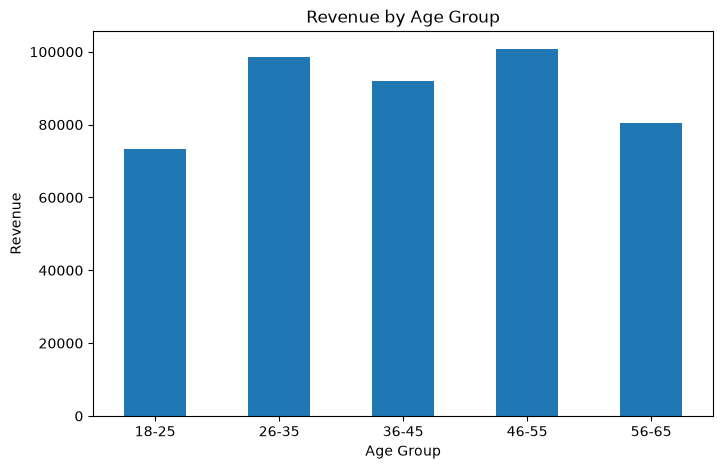

In [19]:
plt.figure(figsize=(8,5))

age_group_sales.plot(kind="bar")

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

## Business Insight

The analysis highlights which age groups contribute the highest revenue.

### Recommendation to Management

Management should focus marketing campaigns and promotional offers on the highest-spending age groups while identifying opportunities to increase engagement among lower-spending segments.

Understanding customer demographics supports more effective business planning and improved customer satisfaction.

# Final Conclusion

## Project Summary

This project analysed a retail sales dataset to uncover meaningful business insights using Python.

The analysis included:

- Data loading and inspection
- Data cleaning and validation
- Revenue analysis
- Product category analysis
- Monthly sales trends
- Customer analysis
- Gender analysis
- Age group analysis

## Key Business Recommendations

1. Maintain sufficient inventory for the highest-performing product categories.

2. Increase promotional campaigns during lower-performing months.

3. Develop loyalty programmes for high-value customers.

4. Use customer demographic insights to create targeted marketing campaigns.

5. Continue using data analytics to support strategic decision-making.

## Skills Demonstrated

This project demonstrates practical experience with:

- Python
- Pandas
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Business Intelligence
- Data Visualisation
- Business Reporting
- Data-driven Decision Making

Thank you for reviewing this project.

# Executive Dashboard

This dashboard provides a high-level summary of the retail sales dataset.

The Key Performance Indicators (KPIs) below give management an immediate overview of business performance before exploring the detailed analysis.

In [20]:
# ============================
# Executive Dashboard
# ============================

total_revenue = df["Total Amount"].sum()
total_transactions = len(df)
total_customers = df["Customer ID"].nunique()
average_sale = df["Total Amount"].mean()

print("=" * 50)
print("      CUSTOMER SALES DASHBOARD")
print("=" * 50)

print(f"Total Revenue      : R{total_revenue:,.2f}")
print(f"Total Transactions : {total_transactions}")
print(f"Total Customers    : {total_customers}")
print(f"Average Sale Value : R{average_sale:,.2f}")

print("=" * 50)

      CUSTOMER SALES DASHBOARD
Total Revenue      : R456,000.00
Total Transactions : 1000
Total Customers    : 1000
Average Sale Value : R456.00


## Executive Dashboard Summary

The dashboard presents four Key Performance Indicators (KPIs) commonly used by management:

- **Total Revenue** measures the overall sales generated.
- **Total Transactions** indicates the number of completed sales.
- **Total Customers** shows the number of unique customers.
- **Average Sale Value** represents the average amount spent per transaction.

These KPIs provide a quick overview of business performance and support strategic decision-making.